The contents of this notebook were created with assistance from Claude generative AI.

# ModernBERT@512 — Hyperparameter Sensitivity (LR & epochs), 5-fold CV

**What this is:** a one-at-a-time (OAT) **local** sensitivity analysis around the 5-fold-CV-tuned
ModernBERT@512 config. We vary **one** hyperparameter at a time and hold everything else at the tuned
recipe (`weight_decay`, `warmup_ratio`, batch size, class-weighting, the same 5 `StratifiedGroupKFold`
folds on `link_id`, and `max_len 512`):

* **Learning rate** — 10 log-spaced points in `[1e-5, 2e-4]` (the grid extends **above** the `5e-5`
  tuning ceiling on purpose, since the tuned LR landed at the edge of the tuning range).
* **Epochs** — 1..8, **faithful per-k runs** (each point trained from scratch for *k* epochs).

The tuned config (tuned LR, 4 epochs) is the **shared centre** of both curves. Every point is scored
by **5-fold grouped CV** on the training pool, so the y-axis is directly comparable to the *Overall
Results* section. Per fold we cached the val probabilities, so the **full metric suite** is available
without retraining: macro-F1[4], macro-F1[3 on-topic], balanced accuracy, accuracy, per-class F1,
per-class PR-AUC, and macro PR-AUC.

> Kernel: **`mads-m2-classifiers`**. The **first code cell runs the sweep** (`sweep_sensitivity.py`
> across both GPUs, ~85 fold-trains, ~2 h) and streams progress including the epoch-timer ETA; set
> `RUN_SWEEP = False` to skip straight to the charts once `sensitivity_results.csv` exists.

In [1]:
# ── run the sweep (notebook interface to sweep_sensitivity.py) ────────────────
# Streams the orchestrator + per-shard worker output, including the [timer] ETA lines. The sweep is
# resumable (cached folds are skipped), so re-running is cheap. Set RUN_SWEEP = False to skip the
# (~2 h) launch and just (re)build the charts from an existing sensitivity_results.csv.
import os, sys, subprocess
from pathlib import Path
SCRIPTS = Path.cwd()        # sweep scripts live here (Project Data - 16)

def launch(scriptargs, keep):
    cmd = [sys.executable, str(SCRIPTS / scriptargs[0]), *scriptargs[1:]]
    print("launching:", " ".join(cmd), "\n", flush=True)
    env = {**os.environ, "PYTHONIOENCODING": "utf-8", "PYTHONUNBUFFERED": "1", "TOKENIZERS_PARALLELISM": "false"}
    proc = subprocess.Popen(cmd, cwd=str(SCRIPTS), stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                            text=True, bufsize=1, env=env)
    for line in proc.stdout:
        s = line.rstrip()
        if s.startswith(keep) or any(k in s for k in ("Error", "Traceback", "Exception", "!!")):
            print(s, flush=True)
    proc.wait(); print("\nexit code:", proc.returncode)

RUN_SWEEP = True          # <- set False to skip the (~2 h) sweep and just plot existing results
if RUN_SWEEP:
    launch(["sweep_sensitivity.py", "--gpus", "0,1"],
           keep=("launching", "configs", "  GPU", "[shard", "merged", "SWEEP DONE", "no shard"))
else:
    print("RUN_SWEEP = False — using the existing sensitivity_results.csv")

launching: <home>\.venvs\mads-m2-classifiers\Scripts\python.exe sweep_sensitivity.py --gpus 0,1 

configs=17  fold-trains=85  total-epochs=360 (= 90 4-epoch-equiv)  gpus=['0', '1']
  GPU0: 8 configs, 180 epoch-folds
  GPU1: 9 configs, 180 epoch-folds
[shard 1] 9 configs x 5 folds  -> results_shard1.csv  (0 epochs to train)
[shard 0] 8 configs x 5 folds  -> results_shard0.csv  (0 epochs to train)
[shard 1] lr4.991e-05_ep7 (lr=4.99e-05 ep=7) fold0: macroF1[4]=0.525 macroPR-AUC=0.555
[shard 0] lr4.991e-05_ep8 (lr=4.99e-05 ep=8) fold0: macroF1[4]=0.511 macroPR-AUC=0.550
[shard 1] lr4.991e-05_ep7 (lr=4.99e-05 ep=7) fold1: macroF1[4]=0.558 macroPR-AUC=0.602
[shard 0] lr4.991e-05_ep8 (lr=4.99e-05 ep=8) fold1: macroF1[4]=0.576 macroPR-AUC=0.613
[shard 1] lr4.991e-05_ep7 (lr=4.99e-05 ep=7) fold2: macroF1[4]=0.561 macroPR-AUC=0.634
[shard 0] lr4.991e-05_ep8 (lr=4.99e-05 ep=8) fold2: macroF1[4]=0.554 macroPR-AUC=0.599
[shard 1] lr4.991e-05_ep7 (lr=4.99e-05 ep=7) fold3: macroF1[4]=0.543 macroPR-AU

In [2]:
import os, sys
P15 = os.getcwd()   # m5_common (shared classifier library)
P16 = os.getcwd()   # sweep_common + this notebook
for p in (P16, P15):
    if p not in sys.path: sys.path.insert(0, p)
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import m5_common as M, sweep_common as S

res = pd.read_csv(S.HERE_CSV)
cfgs = {c["cfg_id"]: c for c in S.build_configs()}
res["lr"]     = res["cfg_id"].map(lambda c: cfgs[c]["lr"])
res["epochs"] = res["cfg_id"].map(lambda c: cfgs[c]["epochs"])

# 5-fold CV mean +/- std (ddof=1) per config
agg = res.groupby("cfg_id")[S.METRICS].agg(["mean", "std"])
agg["lr"]     = [cfgs[c]["lr"] for c in agg.index]
agg["epochs"] = [cfgs[c]["epochs"] for c in agg.index]

LR_SET = agg[np.isclose(agg["epochs"], S.EP0)].sort_values("lr")     # LR sweep: epochs == tuned
EP_SET = agg[np.isclose(agg["lr"], S.LR0)].sort_values("epochs")     # epochs sweep: lr == tuned
print(f"LR sweep points = {len(LR_SET)}   epochs sweep points = {len(EP_SET)}")
print(f"tuned centre: lr={S.LR0:.3e}, epochs={S.EP0}")

LR sweep points = 10   epochs sweep points = 8
tuned centre: lr=4.991e-05, epochs=4


## Fig 1 — headline metrics vs LR and epochs (5-fold CV mean +/- std)

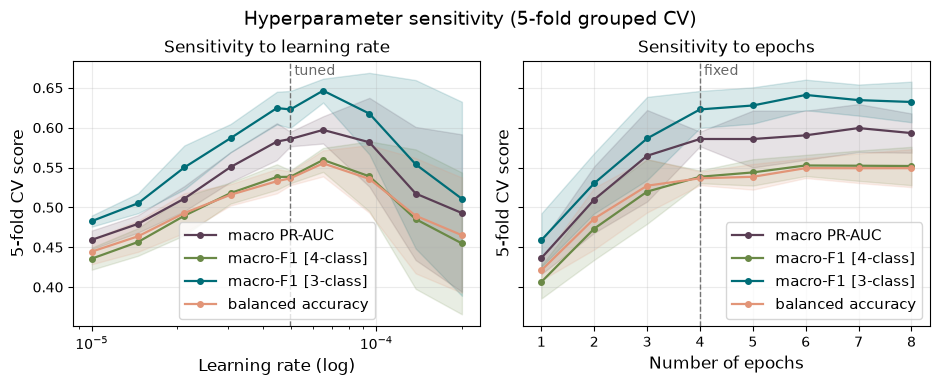

In [8]:
def _panel(ax, sub, xcol, metrics, names, tuned_x, log_x, title, xlabel):
    x = sub[xcol].to_numpy()
    colors = ["#5A3E54", "#6A8946", "#006D77", "#E29578"]

    for m, nm, color in zip(metrics, names, colors):
        mean = sub[(m, "mean")].to_numpy()
        std = sub[(m, "std")].to_numpy()
        ax.plot(x, mean, marker="o", ms=4, lw=1.6, label=nm, color=color)
        ax.fill_between(x, mean - std, mean + std, alpha=0.15, color=color)
    if log_x: 
        ax.set_xscale("log")
        ax.text(tuned_x, ax.get_ylim()[1]-0.004, " tuned", c="0.4", va="top", fontsize=10, rotation=0)
    else:
        ax.text(tuned_x, ax.get_ylim()[1]-0.004, " fixed", c="0.4", va="top", fontsize=10, rotation=0)
    
    ax.axvline(tuned_x, ls="--", c="0.45", lw=1)
    ax.set_title(title)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel("5-fold CV score", fontsize=12)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=11, loc="best")

HEAD  = ["macro_pr_auc", "macro_f1", "macro_f1_3class", "balanced_accuracy"]
HNAME = ["macro PR-AUC", "macro-F1 [4-class]", "macro-F1 [3-class]", "balanced accuracy"]

fig, (axL, axR) = plt.subplots(1, 2, figsize=(9.5, 4), sharey=True)
_panel(axL, LR_SET, "lr", HEAD, HNAME, S.LR0, True,  "Sensitivity to learning rate", "Learning rate (log)")
_panel(axR, EP_SET, "epochs", HEAD, HNAME, S.EP0, False, "Sensitivity to epochs", "Number of epochs")
fig.suptitle("Hyperparameter sensitivity (5-fold grouped CV)", y=.95, fontsize=14)
fig.tight_layout()
fig.savefig("sensitivity_headline.png", dpi=150, bbox_inches="tight")
plt.show()

## Fig 2 — per-class PR-AUC vs LR and epochs

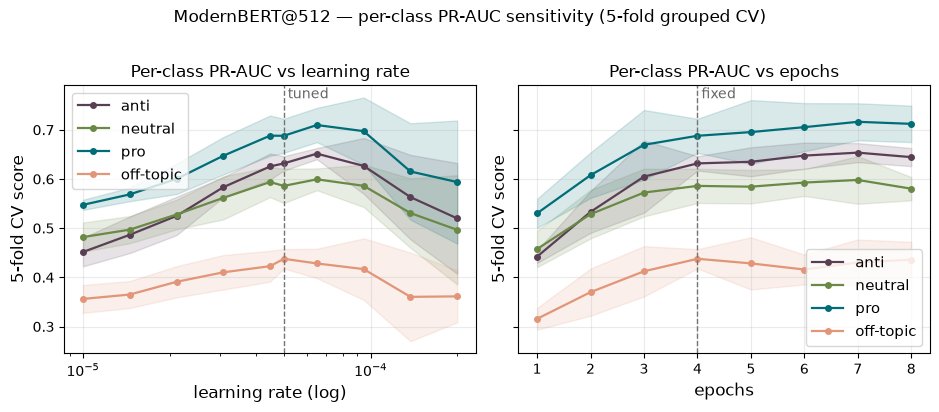

In [4]:
PC  = [f"ap_{l}" for l in M.LABELS]
PCN = list(M.LABELS)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(9.5, 4), sharey=True)
_panel(axL, LR_SET, "lr", PC, PCN, S.LR0, True,  "Per-class PR-AUC vs learning rate", "learning rate (log)")
_panel(axR, EP_SET, "epochs", PC, PCN, S.EP0, False, "Per-class PR-AUC vs epochs", "epochs")
fig.suptitle("ModernBERT@512 — per-class PR-AUC sensitivity (5-fold grouped CV)", y=1.02, fontsize=12)
fig.tight_layout(); fig.savefig("sensitivity_per_class_prauc.png", dpi=150, bbox_inches="tight")
plt.show()

## Mean +/- std tables (written to `sensitivity_cv_meanstd.csv`)

For each sweep, the CV mean +/- std of every metric at every swept value. The tuned-centre row is the
shared point of both sweeps; its numbers should match the ModernBERT row in the Overall Results
(`cv_meanstd.csv`) up to fold-level training noise.

In [5]:
def _table(sub, xcol):
    out = pd.DataFrame(index=sub.index)
    out[xcol] = sub[xcol].values
    for m in S.METRICS:
        out[m] = [f"{mu:.3f} +/- {sd:.3f}" for mu, sd in zip(sub[(m, "mean")], sub[(m, "std")])]
    return out.reset_index(drop=True)

lr_tbl = _table(LR_SET, "lr"); ep_tbl = _table(EP_SET, "epochs")
print("LR sweep (epochs = tuned):");    display(lr_tbl)
print("\nEpochs sweep (lr = tuned):");  display(ep_tbl)

with open("sensitivity_cv_meanstd.csv", "w", encoding="utf-8") as f:
    f.write("# LR sweep (epochs = tuned)\n");   lr_tbl.to_csv(f, index=False)
    f.write("\n# Epochs sweep (lr = tuned)\n");  ep_tbl.to_csv(f, index=False)
print("\nsaved -> sensitivity_headline.png, sensitivity_per_class_prauc.png, sensitivity_cv_meanstd.csv")

LR sweep (epochs = tuned):


,lr,macro_f1,macro_f1_3class,balanced_accuracy,accuracy,f1_anti,f1_neutral,f1_pro,f1_off-topic,ap_anti,ap_neutral,ap_pro,ap_off-topic,macro_pr_auc
0,0.000010,0.436 +/- 0.014,0.483 +/- 0.007,0.444 +/- 0.016,0.446 +/- 0.013,0.437 +/- 0.029,0.443 +/- 0.014,0.488 +/- 0.016,0.375 +/- 0.036,0.452 +/- 0.029,0.482 +/- 0.030,0.547 +/- 0.010,0.356 +/- 0.028,0.459 +/- 0.012
1,0.000015,0.457 +/- 0.017,0.505 +/- 0.013,0.464 +/- 0.020,0.469 +/- 0.018,0.462 +/- 0.033,0.457 +/- 0.034,0.516 +/- 0.026,0.392 +/- 0.040,0.487 +/- 0.037,0.497 +/- 0.028,0.569 +/- 0.014,0.365 +/- 0.027,0.479 +/- 0.011
2,0.000021,0.489 +/- 0.025,0.550 +/- 0.028,0.493 +/- 0.025,0.506 +/- 0.028,0.506 +/- 0.036,0.501 +/- 0.017,0.553 +/- 0.037,0.398 +/- 0.050,0.525 +/- 0.039,0.528 +/- 0.030,0.600 +/- 0.031,0.391 +/- 0.032,0.511 +/- 0.016
3,0.000031,0.518 +/- 0.013,0.587 +/- 0.018,0.516 +/- 0.013,0.543 +/- 0.013,0.543 +/- 0.023,0.516 +/- 0.031,0.607 +/- 0.021,0.406 +/- 0.040,0.583 +/- 0.021,0.562 +/- 0.044,0.647 +/- 0.038,0.410 +/- 0.035,0.551 +/- 0.019
4,0.000045,0.538 +/- 0.016,0.625 +/- 0.020,0.533 +/- 0.015,0.571 +/- 0.017,0.573 +/- 0.018,0.554 +/- 0.039,0.639 +/- 0.017,0.387 +/- 0.028,0.625 +/- 0.026,0.594 +/- 0.031,0.688 +/- 0.041,0.423 +/- 0.031,0.583 +/- 0.023
5,0.000050,0.538 +/- 0.008,0.623 +/- 0.023,0.536 +/- 0.009,0.570 +/- 0.015,0.579 +/- 0.026,0.547 +/- 0.034,0.636 +/- 0.026,0.392 +/- 0.042,0.632 +/- 0.015,0.586 +/- 0.035,0.688 +/- 0.035,0.438 +/- 0.020,0.586 +/- 0.009
6,0.000065,0.560 +/- 0.015,0.646 +/- 0.015,0.555 +/- 0.016,0.593 +/- 0.014,0.611 +/- 0.020,0.561 +/- 0.014,0.656 +/- 0.021,0.410 +/- 0.043,0.652 +/- 0.011,0.599 +/- 0.022,0.710 +/- 0.035,0.428 +/- 0.030,0.597 +/- 0.017
7,0.000095,0.539 +/- 0.044,0.618 +/- 0.051,0.536 +/- 0.042,0.567 +/- 0.050,0.574 +/- 0.053,0.546 +/- 0.038,0.630 +/- 0.060,0.405 +/- 0.037,0.627 +/- 0.057,0.586 +/- 0.043,0.697 +/- 0.068,0.417 +/- 0.063,0.582 +/- 0.056
8,0.000138,0.485 +/- 0.087,0.554 +/- 0.106,0.489 +/- 0.072,0.506 +/- 0.105,0.519 +/- 0.093,0.500 +/- 0.055,0.552 +/- 0.157,0.370 +/- 0.057,0.563 +/- 0.086,0.531 +/- 0.071,0.615 +/- 0.098,0.360 +/- 0.090,0.517 +/- 0.084
9,0.000200,0.455 +/- 0.089,0.511 +/- 0.122,0.465 +/- 0.072,0.476 +/- 0.092,0.511 +/- 0.065,0.432 +/- 0.125,0.504 +/- 0.157,0.372 +/- 0.023,0.520 +/- 0.113,0.497 +/- 0.111,0.594 +/- 0.125,0.361 +/- 0.053,0.493 +/- 0.099



Epochs sweep (lr = tuned):


,epochs,macro_f1,macro_f1_3class,balanced_accuracy,accuracy,f1_anti,f1_neutral,f1_pro,f1_off-topic,ap_anti,ap_neutral,ap_pro,ap_off-topic,macro_pr_auc
0,1,0.406 +/- 0.021,0.459 +/- 0.034,0.421 +/- 0.012,0.421 +/- 0.030,0.438 +/- 0.029,0.416 +/- 0.037,0.442 +/- 0.100,0.330 +/- 0.021,0.442 +/- 0.013,0.458 +/- 0.037,0.530 +/- 0.030,0.316 +/- 0.022,0.436 +/- 0.020
1,2,0.473 +/- 0.039,0.530 +/- 0.038,0.486 +/- 0.039,0.484 +/- 0.038,0.511 +/- 0.057,0.483 +/- 0.027,0.513 +/- 0.038,0.387 +/- 0.053,0.533 +/- 0.043,0.528 +/- 0.049,0.608 +/- 0.046,0.370 +/- 0.048,0.510 +/- 0.042
2,3,0.520 +/- 0.040,0.586 +/- 0.052,0.527 +/- 0.034,0.537 +/- 0.049,0.559 +/- 0.049,0.524 +/- 0.030,0.585 +/- 0.072,0.411 +/- 0.019,0.605 +/- 0.073,0.572 +/- 0.048,0.669 +/- 0.071,0.412 +/- 0.051,0.565 +/- 0.057
3,4,0.538 +/- 0.008,0.623 +/- 0.023,0.536 +/- 0.009,0.570 +/- 0.015,0.579 +/- 0.026,0.547 +/- 0.034,0.636 +/- 0.026,0.392 +/- 0.042,0.632 +/- 0.015,0.586 +/- 0.035,0.688 +/- 0.035,0.438 +/- 0.020,0.586 +/- 0.009
4,5,0.544 +/- 0.017,0.628 +/- 0.023,0.538 +/- 0.016,0.577 +/- 0.020,0.590 +/- 0.027,0.542 +/- 0.034,0.645 +/- 0.020,0.399 +/- 0.023,0.635 +/- 0.030,0.584 +/- 0.034,0.695 +/- 0.065,0.428 +/- 0.053,0.586 +/- 0.036
5,6,0.553 +/- 0.013,0.641 +/- 0.019,0.549 +/- 0.012,0.585 +/- 0.020,0.600 +/- 0.017,0.563 +/- 0.012,0.650 +/- 0.034,0.397 +/- 0.011,0.648 +/- 0.026,0.593 +/- 0.027,0.705 +/- 0.049,0.416 +/- 0.030,0.590 +/- 0.031
6,7,0.552 +/- 0.019,0.635 +/- 0.019,0.549 +/- 0.019,0.583 +/- 0.019,0.591 +/- 0.023,0.552 +/- 0.038,0.655 +/- 0.023,0.411 +/- 0.024,0.654 +/- 0.019,0.598 +/- 0.048,0.716 +/- 0.038,0.430 +/- 0.047,0.600 +/- 0.030
7,8,0.552 +/- 0.024,0.632 +/- 0.025,0.549 +/- 0.024,0.581 +/- 0.026,0.582 +/- 0.019,0.558 +/- 0.024,0.650 +/- 0.037,0.417 +/- 0.037,0.644 +/- 0.018,0.580 +/- 0.024,0.712 +/- 0.037,0.436 +/- 0.036,0.593 +/- 0.025



saved -> sensitivity_headline.png, sensitivity_per_class_prauc.png, sensitivity_cv_meanstd.csv
